## arXiv corpus — read this first

This is the **arXiv** twin of the S2ORC notebook, generated by
`accelscan.scripts.make_arxiv_notebooks`. Edit the S2ORC original and regenerate.

Four things make arXiv levels **not** comparable to S2ORC levels:

1. **Self-selected preprints**, skewed to physics and CS, with no peer-review filter.
2. **Raw-LaTeX matching.** The matcher reads the `.tex` source, which includes figure
   captions, spec tables, code listings and `%` comments that GROBID drops from
   S2ORC. This biases any-mention prevalence *upward*; `reported use` and
   model-specific series are better protected because the LLM judges the passage.
3. **No citations.** There is no arXiv→corpusid crosswalk, so §6.4-style citation
   analyses are absent here.
4. **1991–2026 available, 2005–2026 analysed.** 2026 is a partial calendar year:
   fine for shares, marked on counts.

Only **within-corpus trends** should be compared across the two corpora.


# §4 General Trends — accelerator reporting across science

Establishes the phenomenon before any capacity or lifecycle estimates: how much
of science reports accelerator use, how *specifically* it reports it, in what
context, and how that differs by field.

**Denominator discipline.** Every share here is over the arXiv full-text
population (`denominator.parquet`, one row per full-text paper), not over
accelerator papers — so "0 mentions" papers are in the base. Full-text coverage
by field-year is plotted first, because a change in corpus ingestion can
masquerade as a change in GPU adoption.

Inputs: `python -m accelscan.denominator` (denominator + paper_flags tables).

In [9]:
import os

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.registry import load_registry
from accelscan.s3 import storage_options
from accelscan.plotting import setup_figures
from accelscan.meta import paper_fields
from accelscan.paths import (analytic_base, candidates_root, capacity_key,
                             get_corpus, precision_key, s3_uri)

# integer year ticks + every figure exported to output/analysis/trends/
setup_figures('arxiv/trends')

## Knobs

In [10]:
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2026
LOCAL_ANALYTIC = None      # e.g. 'output/analytic_smoke'
TOP_FIELDS = 8            # fields ranked by papers with ANY accelerator mention
MIN_PAPERS = 200           # suppress field-years with too little support

PAL = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9',
       '#999999', '#000000']
reg = load_registry(); so = storage_options()
CORPUS = 'arxiv'
c = get_corpus(CORPUS); KEY = c.key      # 'paper_id'; corpusid is null for arXiv

# arXiv's group names are too long for legends and axis ticks. Applied at every point
# `field` enters, so the short form is what every figure and table shows.
FIELD_LABELS = {'Electrical Engineering and Systems Science': 'EE and Systems',
                'Quantitative Biology': 'Quant. Biology',
                'Quantitative Finance': 'Quant. Finance'}
short_fields = lambda df: df.with_columns(pl.col('field').replace(FIELD_LABELS))


## Load analytic tables

In [11]:
base = (LOCAL_ANALYTIC or
        s3_uri(analytic_base(c, reg.version, PROMPT_VERSION, MODEL_TAG)))
rd = (lambda name: pl.read_parquet(f'{base}/{name}.parquet')) if LOCAL_ANALYTIC else \
     (lambda name: pl.read_parquet(f'{base}/{name}.parquet', storage_options=so))

den = short_fields(rd('denominator'))
flags = rd('paper_flags')
papers = (den.join(flags, on=KEY, how='left')
          .with_columns(
              accel_any=pl.col('accel_any').fill_null(False),
              accel_used=pl.col('accel_used').fill_null(False),
              model_specific=pl.col('model_specific').fill_null(False),
              model_specific_used=pl.col('model_specific_used').fill_null(False),
              is_candidate=pl.col('is_candidate').fill_null(False))
          .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
print(f'{papers.height:,} full-text papers {YEAR_MIN}-{YEAR_MAX} | '
      f'{papers["accel_any"].sum():,} with an accelerator mention | '
      f'{papers["accel_used"].sum():,} reporting use')

2,541,291 full-text papers 2005-2026 | 295,340 with an accelerator mention | 235,381 reporting use


## 4.0 Corpus composition (read this before any trend)

Full-text papers per year and the share of the corpus each field contributes.
Discontinuities here propagate into every share below.

top 8 fields by any-mention papers: Computer Science, Physics, EE and Systems, Mathematics, Statistics, Quant. Biology, Quant. Finance, Economics


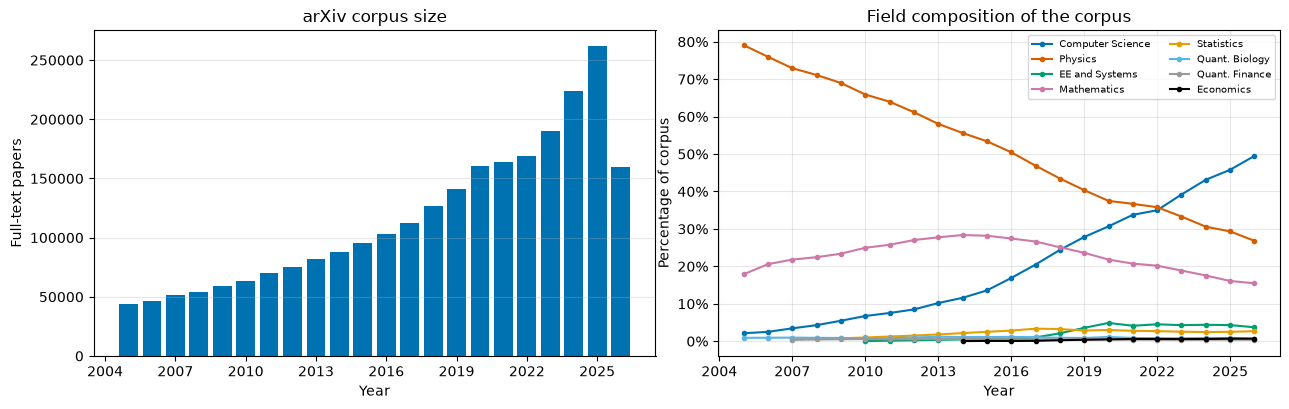

In [12]:
cy = papers.group_by('year').agg(papers=pl.len()).sort('year')
# One definition of "top fields" for every figure in the repo: the raw number of
# papers reporting ANY accelerator mention (not corpus size, and not restricted to
# used-in-this-work). Ranking by corpus size would foreground fields that barely
# touch accelerators; ranking by used-in-this-work would drop fields that discuss
# hardware without running it.
fields_top = (papers.filter(pl.col('field').is_not_null() & pl.col('accel_any'))
              .group_by('field').agg(n=pl.len()).sort('n', descending=True)
              .head(TOP_FIELDS)['field'].to_list())
print(f'top {TOP_FIELDS} fields by any-mention papers: ' + ', '.join(fields_top))
fy = (papers.filter(pl.col('field').is_in(fields_top))
      .group_by('year', 'field').agg(n=pl.len()).sort('year'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(cy['year'], cy['papers'], color='#0072B2')
axes[0].set(xlabel='Year', ylabel='Full-text papers', title='arXiv corpus size')
axes[0].grid(alpha=0.3, axis='y')
tot = dict(zip(cy['year'].to_list(), cy['papers'].to_list()))
for i, f in enumerate(fields_top):
    s = fy.filter(pl.col('field') == f)
    axes[1].plot(s['year'], [100 * n / tot[y] for y, n in zip(s['year'], s['n'])],
                 marker='.', label=f, color=PAL[i % len(PAL)])
axes[1].set(xlabel='Year', ylabel='Percentage of corpus', title='Field composition of the corpus')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.0b Same two facts in one panel

Stacked bars of **absolute** counts carry both quantities on a single ruler: bar
*height* is the corpus size, each segment's *thickness* is that field's
contribution. Deliberately not a second y-axis — two y-scales put the total and
the shares on incommensurate rulers, and the reader can't tell which mark belongs
to which axis. Flip `STACK_NORMALIZE` for the pure composition (100%-stacked) view.

Unlike the panel above, this one is **exhaustive**: every full-text paper lands in
some segment. Fields outside the top `TOP_FIELDS` become *Other fields*, and papers
with no arXiv's own taxonomy at all become *No field label* (hatched) — the panel above
drops both, which is why its shares don't sum to 100.


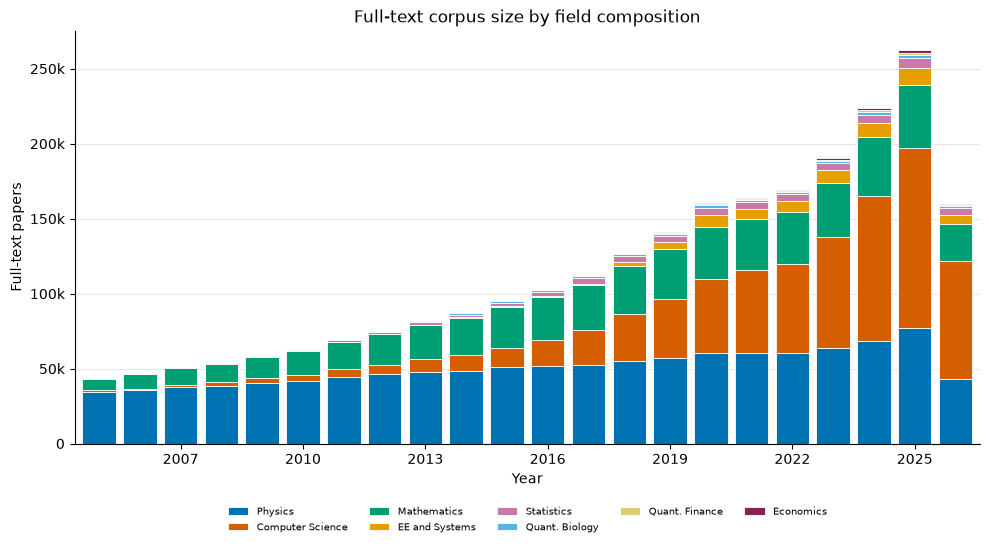

In [13]:
# Corpus size AND field composition in one panel (second version of 4.0).
STACK_NORMALIZE = False    # True = 100%-stacked: composition only, size dropped

# Segment colors: Okabe-Ito house palette, ORDERED so that segments adjacent in
# the stack stay separable for colorblind readers (checked in OKLab: worst
# adjacent pair dE = 20.0 normal / 10.1 deuteranopia, against floors of 15 / 8).
# Yellow and black are swapped for sand/wine, which hold up as large area fills.
STACK_PAL = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9',
             '#DDCC77', '#882255']
# The two residual segments are kept SEPARATE and named: "other" (a real field,
# just outside the top-N) and "no label" (no arXiv category at all) are different
# facts, and lumping them hides how much of the corpus is simply unclassified.
# The unlabeled segment is hatched so it never reads as another field, and so the
# two neutral grays next to each other stay distinguishable.
OTHER, NOLAB = 'Other fields', 'No field label'

order = (papers.filter(pl.col('field').is_in(fields_top)).group_by('field')
         .agg(n=pl.len()).sort('n', descending=True)['field'].to_list())
# segments = order + [OTHER, NOLAB]
segments = order
COLOR = {f: STACK_PAL[i % len(STACK_PAL)] for i, f in enumerate(order)}
COLOR[OTHER], COLOR[NOLAB] = '#BBBBBB', '#EEEEEE'
HATCH = {NOLAB: '///'}

piv = (papers.with_columns(
           seg=pl.when(pl.col('field').is_null()).then(pl.lit(NOLAB))
                 .when(pl.col('field').is_in(fields_top)).then(pl.col('field'))
                 .otherwise(pl.lit(OTHER)))
       .group_by('year', 'seg').agg(n=pl.len())
       .pivot(on='seg', index='year', values='n').fill_null(0).sort('year'))
yr = piv['year'].to_numpy()
Y = np.array([piv[s].to_numpy() if s in piv.columns else np.zeros(piv.height)
              for s in segments], dtype=float)
total = Y.sum(axis=0)
assert total.sum() == papers.height, 'segments must partition the corpus'
Z = 100 * Y / total if STACK_NORMALIZE else Y

fig, ax = plt.subplots(figsize=(10, 5.6))
bottom = np.zeros(len(yr))
for s, row in zip(segments, Z):
    ax.bar(yr, row, bottom=bottom, width=0.82, label=s, color=COLOR[s],
           hatch=HATCH.get(s), edgecolor='white', linewidth=0.6)
    bottom += row

# No inline segment labels: with 10 segments the text spans neighbouring bars and
# reads as if it belonged to them. Identity comes from the legend below, whose
# reading order matches the stack order, plus the hatch on the unlabeled segment.
if STACK_NORMALIZE:
    ax.set(ylabel='Percentage of full-text corpus', ylim=(0, 100))
else:
    ax.set(ylabel='Full-text papers')
    ax.yaxis.set_major_formatter(lambda v, _: '0' if not v else
                                 f'{v*1e-6:g}M' if v >= 1e6 else f'{v*1e-3:g}k')
    # ax.annotate(f'{total[-1]:,.0f} papers in {yr[-1]}',
    #             xy=(yr[-1], total[-1]), xytext=(-4, 8), textcoords='offset points',
    #             ha='right', fontsize=8, color='#555555')
ax.set(xlabel='Year', xlim=(yr[0] - 0.6, yr[-1] + 0.6),
       title=f'Full-text corpus: field composition' if STACK_NORMALIZE
             else f'Full-text corpus size by field composition')
# legend below the plot: in the 100%-stacked view there is no empty corner for it
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=5,
          fontsize=7.5, frameon=False)
ax.grid(alpha=0.3, axis='y'); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 4.1 Prevalence of accelerator reporting, overall and by field

**Left:** three nested series over the whole full-text corpus — any mention,
reported *use* (`used-in-this-work`), and model-specific use. The gap between "any
mention" and "use" is what the usage-context classifier buys: papers that merely
discuss GPUs are not counted as using them.

**Right:** the same "reports use" quantity decomposed by field, with the
corpus-wide rate repeated as a black reference line so the two panels read as
aggregate-then-decomposed. Note the denominator changes across panels — left is
per full-text paper, right is per *field* paper. Fields outside the top
`TOP_FIELDS` are pooled into *Other fields* (dashed) rather than dropped, so a
low-adoption long tail can't hide off-plot; colors are shared with 4.0b, so a
field keeps its identity across figures. Papers with no arXiv's own taxonomy are
excluded from the right panel — they have no field to compare.

*Simplified:* the by-field panel previously sat in its own §4.4 next to an
adoption-lag panel (the year each field first crossed 1% and 5%, and its lag
behind the earliest field). That lag panel was removed, so the field
first-crossing years (CS 2005 → Mathematics 2024) are no longer computed anywhere
in the repo — re-add a printed table if the draft cites them.


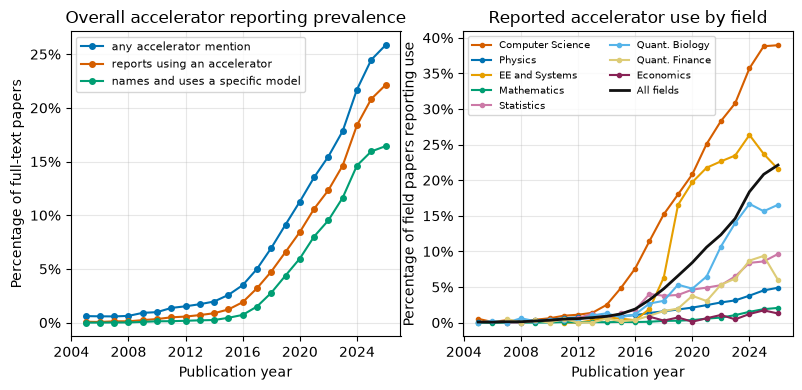

shape: (22, 6)
┌──────┬────────┬───────────┬────────────┬─────────────────┬────────────┐
│ year ┆ n      ┆ any_share ┆ used_share ┆ modelspec_share ┆ cand_share │
│ ---  ┆ ---    ┆ ---       ┆ ---        ┆ ---             ┆ ---        │
│ i32  ┆ u32    ┆ f64       ┆ f64        ┆ f64             ┆ f64        │
╞══════╪════════╪═══════════╪════════════╪═════════════════╪════════════╡
│ 2005 ┆ 43670  ┆ 0.0061    ┆ 0.0008     ┆ 0.0             ┆ 0.008679   │
│ 2006 ┆ 46686  ┆ 0.0059    ┆ 0.0006     ┆ 0.0             ┆ 0.008204   │
│ 2007 ┆ 51285  ┆ 0.0058    ┆ 0.0012     ┆ 0.0001          ┆ 0.007741   │
│ 2008 ┆ 54122  ┆ 0.0063    ┆ 0.0012     ┆ 0.0001          ┆ 0.008462   │
│ 2009 ┆ 58758  ┆ 0.0091    ┆ 0.0023     ┆ 0.0007          ┆ 0.011284   │
│ 2010 ┆ 63174  ┆ 0.0098    ┆ 0.0033     ┆ 0.0013          ┆ 0.012109   │
│ 2011 ┆ 69813  ┆ 0.0137    ┆ 0.0049     ┆ 0.0013          ┆ 0.017475   │
│ 2012 ┆ 75403  ┆ 0.0152    ┆ 0.0056     ┆ 0.0017          ┆ 0.018872   │
│ 2013 ┆ 82318  ┆ 0.017

In [14]:
pv = (papers.group_by('year').agg(
        n=pl.len(),
        any_share=pl.col('accel_any').mean(),
        used_share=pl.col('accel_used').mean(),
        modelspec_share=pl.col('model_specific_used').mean(),
        cand_share=pl.col('is_candidate').mean())
      .filter(pl.col('n') >= MIN_PAPERS).sort('year'))

# Residual fields are pooled, not dropped (same segmentation as 4.0b); papers with
# a null field are left out, since "no field" has nothing to compare across fields.
fd = (papers.filter(pl.col('field').is_not_null())
      .with_columns(seg=pl.when(pl.col('field').is_in(fields_top))
                          .then(pl.col('field')).otherwise(pl.lit(OTHER)))
      .group_by('seg', 'year').agg(n=pl.len(), used=pl.col('accel_used').mean())
      .filter(pl.col('n') >= 100).sort('year'))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for lbl, col, c in [('any accelerator mention', 'any_share', '#0072B2'),
                    ('reports using an accelerator', 'used_share', '#D55E00'),
                    ('names and uses a specific model', 'modelspec_share', '#009E73')]:
    axes[0].plot(pv['year'], 100 * pv[col], marker='o', ms=4, label=lbl, color=c)
axes[0].set(xlabel='Publication year', ylabel='Percentage of full-text papers',
            title='Overall accelerator reporting prevalence')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for i, f in enumerate(fields_top + [OTHER]):
    s = fd.filter(pl.col('seg') == f)
    if s.height > 2:
        axes[1].plot(s['year'], 100 * s['used'], marker='.', label=f,
                     color=COLOR.get(f, PAL[i % len(PAL)]),
                     ls='--' if f == OTHER else '-')
# the left panel's "reports use" line, for scale: which fields sit above/below it
axes[1].plot(pv['year'], 100 * pv['used_share'], color='#111111', lw=2,
             label='All fields', zorder=5)
axes[1].set(xlabel='Publication year',
            ylabel='Percentage of field papers reporting use',
            title='Reported accelerator use by field')
axes[1].legend(fontsize=7, ncol=2, loc='upper left'); axes[1].grid(alpha=0.3)

# fig.suptitle('Accelerator reporting prevalence, overall and by field')
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25):
    print(pv.with_columns(pl.col('any_share').round(4), pl.col('used_share').round(4),
                          pl.col('modelspec_share').round(4)))

## 4.2 The measurement funnel and reporting specificity

**Left:** our own funnel, from full-text papers to analyzed mentions — publish it
so readers can see where the population narrows (filter → LLM → usage
restriction), before reading any finding that rests on it.

**Right:** among papers that report *using* an accelerator, what share name a
specific model rather than only "a GPU"? This is a measurement-practice trend with
a direct policy hook: reproducibility/reporting standards for compute (an analogue
of CONSORT/PRISMA checklists). A flat or declining line means the literature is
getting *less* auditable even as compute grows.

The two panels answer the same question from opposite ends: the left is how much of
the corpus *we* retain in order to measure hardware, the right is how specifically
*authors* report it. The final funnel step is the numerator of the right panel's
last point.

*Note:* the funnel previously stood alone as §4.4.


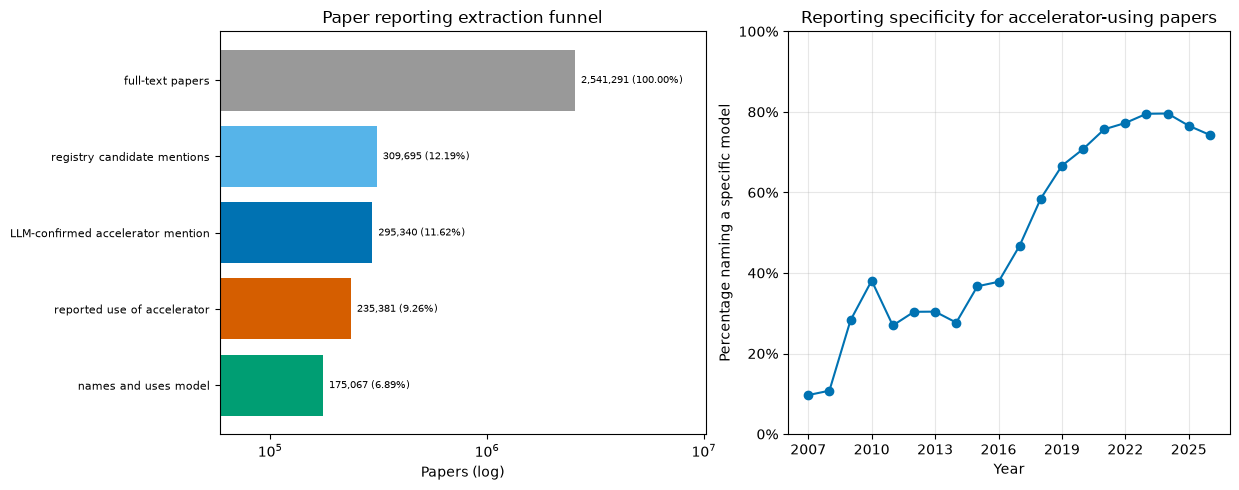

shape: (20, 3)
┌──────┬───────┬──────────┐
│ year ┆ n     ┆ specific │
│ ---  ┆ ---   ┆ ---      │
│ i32  ┆ u32   ┆ f64      │
╞══════╪═══════╪══════════╡
│ 2007 ┆ 62    ┆ 0.097    │
│ 2008 ┆ 65    ┆ 0.108    │
│ 2009 ┆ 138   ┆ 0.283    │
│ 2010 ┆ 210   ┆ 0.381    │
│ 2011 ┆ 345   ┆ 0.27     │
│ …    ┆ …     ┆ …        │
│ 2022 ┆ 20888 ┆ 0.772    │
│ 2023 ┆ 27840 ┆ 0.795    │
│ 2024 ┆ 41086 ┆ 0.796    │
│ 2025 ┆ 54583 ┆ 0.766    │
│ 2026 ┆ 35362 ┆ 0.743    │
└──────┴───────┴──────────┘
   2,541,291  100.00%  full-text papers
     309,695   12.19%  registry candidate mentions
     295,340   11.62%  LLM-confirmed accelerator mention
     235,381    9.26%  reported use of accelerator
     175,067    6.89%  names and uses model


In [15]:
sp = (papers.filter(pl.col('accel_used'))
      .group_by('year').agg(n=pl.len(),
                            specific=pl.col('model_specific_used').mean())
      .filter(pl.col('n') >= 50).sort('year'))
funnel = {
    'full-text papers': papers.height,
    'registry candidate mentions': int(papers['is_candidate'].sum()),
    'LLM-confirmed accelerator mention': int(papers['accel_any'].sum()),
    'reported use of accelerator': int(papers['accel_used'].sum()),
    'names and uses model': int(papers['model_specific_used'].sum()),
}

# the funnel gets the extra width its category labels and value annotations need;
# the specificity panel stays square (as set in 4.2)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), width_ratios=[1.1, 1])
labels, vals = list(funnel), list(funnel.values())
axes[0].barh(range(len(vals)), vals,
             color=['#999999', '#56B4E9', '#0072B2', '#D55E00', '#009E73'])
axes[0].set_yticks(range(len(vals))); axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_xscale('log'); axes[0].invert_yaxis()
for i, v in enumerate(vals):
    axes[0].text(v, i, f'  {v:,} ({100*v/vals[0]:.2f}%)', va='center', fontsize=7)
# headroom so the value annotations don't run past the spine
axes[0].set_xlim(min(vals) / 3, max(vals) * 4)
axes[0].set(xlabel='Papers (log)', title='Paper reporting extraction funnel')

axes[1].plot(sp['year'], 100 * sp['specific'], marker='o', color='#0072B2')
axes[1].set(xlabel='Year', ylabel='Percentage naming a specific model', ylim=(0, 100),
            title='Reporting specificity for accelerator-using papers')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(sp.with_columns(pl.col('specific').round(3)))
for k, v in funnel.items():
    print(f'{v:12,}  {100*v/vals[0]:6.2f}%  {k}')

## 4.3 Mention-context mix

How accelerators appear when they appear: used here, discussed as prior work,
studied as the object of research, or speculative. Validates that the
usage-context labels behave sensibly over time and shows how much of the
literature would be miscounted by a naive "any mention = use" rule.

/tmp/ipykernel_3145491/3402622893.py:4: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode('usage_contexts').rename({'usage_contexts': 'ctx'})


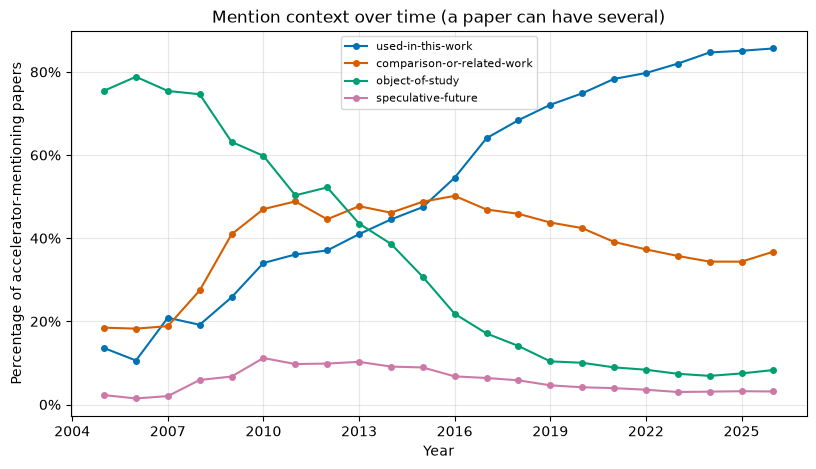

In [16]:
ctx = (flags.select(KEY, 'usage_contexts')
       .join(den.select(KEY, 'year'), on=KEY, how='inner')
       .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX))
       .explode('usage_contexts').rename({'usage_contexts': 'ctx'})
       .filter(pl.col('ctx').is_not_null()))
tot = ctx.group_by('year').agg(n=pl.col(KEY).n_unique())
cs = (ctx.group_by('year', 'ctx').agg(k=pl.col(KEY).n_unique())
      .join(tot, on='year').with_columns(share=pl.col('k') / pl.col('n'))
      .filter(pl.col('n') >= 100).sort('year'))
fig, ax = plt.subplots(figsize=(9.5, 5))
for i, c in enumerate(['used-in-this-work', 'comparison-or-related-work',
                       'object-of-study', 'speculative-future']):
    s = cs.filter(pl.col('ctx') == c)
    ax.plot(s['year'], 100 * s['share'], marker='o', ms=4, label=c, color=PAL[i])
ax.set(xlabel='Year', ylabel='Percentage of accelerator-mentioning papers',
       title='Mention context over time (a paper can have several)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()